# 🧠🤖 Atividade - Regressão de Seno com Descida do Gradiente

O objetivo da atividade é utilizar o algoritmo de descida do gradiente para realizar regressão de uma função seno, isto é, encontrar uma versão da função seno que mais se ajusta a um conjunto de pontos. Considere o seguinte conjunto de pontos:

In [1]:
import numpy as np

def ler_dados(path):
    with open(path, "r") as f:
        data = [line.split() for line in f.readlines()]
    data = np.array(data, dtype=np.float32)

    x = data[:, 0]
    y = data[:, 1]

    return x, y

x, y = ler_dados("data-1.txt")
x, y

(array([-10. ,  -9.5,  -9. ,  -8.5,  -8. ,  -7.5,  -7. ,  -6.5,  -6. ,
         -5.5,  -5. ,  -4.5,  -4. ,  -3.5,  -3. ,  -2.5,  -2. ,  -1.5,
         -1. ,  -0.5,   0. ,   0.5,   1. ,   1.5,   2. ,   2.5,   3. ,
          3.5,   4. ,   4.5,   5. ,   5.5,   6. ,   6.5,   7. ,   7.5,
          8. ,   8.5,   9. ,   9.5], dtype=float32),
 array([-3.049163  , -2.6773899 , -2.6716516 , -2.0710213 , -1.50771   ,
        -1.1924514 , -0.8683805 , -0.96150565, -1.2023299 , -1.8061168 ,
        -2.501456  , -3.0539794 , -3.2620528 , -3.1245124 , -2.9112937 ,
        -2.2453938 , -2.3087683 , -1.2598307 , -1.0636746 , -0.92266905,
        -0.8786576 , -1.729784  , -2.0099556 , -2.7642746 , -3.3521018 ,
        -3.3026602 , -3.272684  , -2.5428126 , -2.0814285 , -1.5314364 ,
        -1.2280508 , -0.8279353 , -1.1286899 , -1.5215187 , -1.8100852 ,
        -2.271931  , -2.940685  , -2.8459418 , -3.323826  , -2.8045368 ],
       dtype=float32))

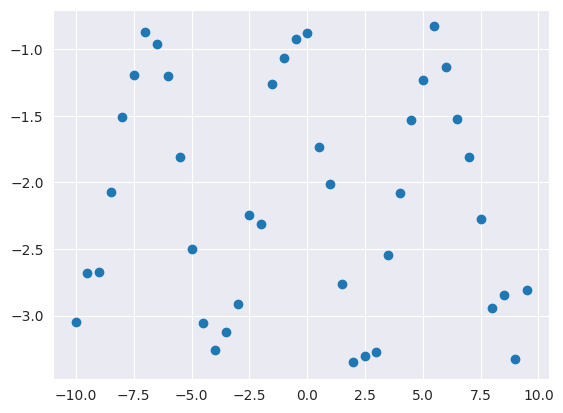

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

plt.plot(x, y, 'o')

Dada a função $f(x) = \sin(x + a) + b$, queremos encontrar os valores dos coeficientes $a$ e $b$ que minimizem o erro médio quadrático em relação aos pontos acima:

$$
loss = \frac{1}{n} \sum_{i=1}^{n} \left( y_i - f(x_i) \right) ^2 = \frac{1}{n} \sum_{i=1}^{n} \left( y_i - \sin(a + x) - b) \right) ^2
$$

---

# Tarefas

## Implementação com Pytorch

### Tarefa: Use pytorch e as funções acima para implementar o algoritmo de descida do gradiente. Lembre-se de usar as funções do pytorch nas implementações (e.g., `torch.sin`, `torch.square`, `torch.mean`, etc.).

In [6]:
# resposta

import torch

def calcula_funcao(a, b, x):
    # implementa a função f(x) = sin(x + a) + b usando pytorch
    return torch.sin(x + a) + b

def loss_fn(y_real, y_predito):
    # calcula o erro médio quadrático entre o y predito e o y real
    return torch.mean(torch.square(y_real - y_predito))


def gradient_descent_torch(x, y, n_epochs, lr):
    # inicializa coeficientes com valores aleatórios
    a = torch.randn(1, requires_grad=True)
    b = torch.randn(1, requires_grad=True)

    # transforma o dataset em tensores
    x = torch.from_numpy(x)
    y = torch.from_numpy(y)

    # salva o valor da perda e dos parametros antes de comecar o treinamento
    y_prd = calcula_funcao(a, b, x)
    history = [{"loss": loss_fn(y, y_prd).item(), "params": [a.item(), b.item()]}]

    # itera por varias epocas
    for _ in range(n_epochs):
        y_prd = calcula_funcao(a, b, x)
        loss = loss_fn(y, y_prd)

        # calcula a derivada parcial do erro em relação aos parâmetros
        loss.backward()

        # atualiza os valores dos parâmetros usando descida do gradiente
        with torch.no_grad():
            a -= lr * a.grad
            b -= lr * b.grad

        # reseta os gradientes para zero
        a.grad.zero_()
        b.grad.zero_()

        # salva o valor da loss e os valores dos coeficientes nesta época
        y_prd = calcula_funcao(a, b, x)
        loss = loss_fn(y, y_prd)
        history.append({"loss": loss.item(), "params": [a.item(), b.item()]})

    return history

history = gradient_descent_torch(x, y, 20, 1e-1)
for epoch in history:
    print(epoch['loss'])

10.910794258117676
7.514634132385254
5.281858921051025
3.792379379272461
2.7797372341156006
2.075698137283325
1.57443106174469
1.209334135055542
0.938159167766571
0.733617901802063
0.5775875449180603
0.4576259255409241
0.3648993670940399
0.29295945167541504
0.23699712753295898
0.19337433576583862
0.15931358933448792
0.132680281996727
0.11182836443185806
0.09548451006412506
0.08266109228134155


A célula abaixo mostra a evolução da função de perda e a função antes e depois do treinamento. 

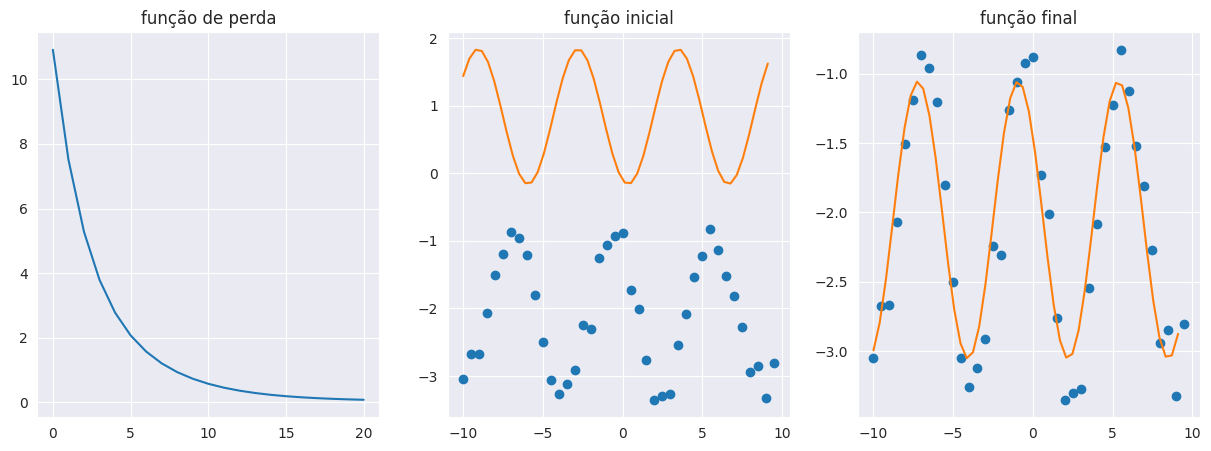

In [7]:
def plota_funcao(x, y, a, b):
    step = (x.max() - x.min()) / 50
    view_x = np.arange(x.min(), x.max(), step)
    with torch.no_grad():
        view_y = calcula_funcao(a, b, torch.from_numpy(view_x)).numpy()
    plt.plot(x, y, 'o')
    plt.plot(view_x, view_y, '-')

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("função de perda")
plt.plot([epoch['loss'] for epoch in history], '-')

plt.subplot(1, 3, 2)
plt.title("função inicial")
a, b =  history[0]["params"]
plota_funcao(x, y, a, b)

plt.subplot(1, 3, 3)
plt.title("função final")
a, b =  history[-1]["params"]
plota_funcao(x, y, a, b)


--- 

## Implementação sem pytorch

### Tarefa: Desenhe o grafo computacional resultante do cálculo do erro para um ponto $(x_i, y_i)$, isto é, o valor da expressão dentro do somatório.

*Clique duas vezes para adicionar sua resposta*

### Tarefa: Calcule as derivadas parciais do erro em relação os parâmetros $a$ e $b$.

*Clique duas vezes para adicionar sua resposta*

### Tarefa: Implemente a função dados os valores de a, b e xi:

In [9]:
# resposta
import numpy as np

def calcula_funcao(a, b, xi):
    return np.sin(xi + a) + b

calcula_funcao(2, 3, 3)

np.float64(2.0410757253368614)

### Tarefa: Implemente uma função para calcular o valor da função de perda considerando todos os pontos do dataset e os valores atuais dos coeficientes:

In [17]:
def loss_fn(a, b, x, y):
    return sum([(yi - calcula_funcao(a, b, xi))**2 for xi, yi in zip(x, y)])/len(x)



### Tarefa: Implemente uma função que calcule os valores das derivadas parciais em relação aos coeficientes para um ponto $(x_i, y_i)$ específico: 

In [18]:
def derivadas_parciais_xi(a, b, xi, yi):
    return [-2*np.cos(a + xi)*(yi - np.sin(a + xi) - b), -2*(yi - np.sin(a + xi) - b)]

### Tarefa: Implemente uma função que calcule as derivadas parciais em relação aos coeficientes para todo o dataset. Como estamos usando o MSE, o gradiente total será a média dos gradientes para cada ponto.

In [19]:
def calcula_gradiente(a, b, x, y):
    dp = [derivadas_parciais_xi(a, b, xi, yi) for xi, yi in zip(x, y)]
    return [sum(i[0] for i in dp)/len(x), sum(i[1] for i in dp)/len(x)]

calcula_gradiente(2, 3, x, y)

[np.float32(-0.123255625), np.float32(10.133331)]

### Tarefa: Use as funções para desenvolver uma função que implemente o algoritmo de descida do gradiente. 

In [20]:
def gradient_descent(x, y, n_epochs, lr):
    # inicializa coeficientes com valores aleatórios
    a = np.random.rand()
    b = np.random.rand()

    # salva o valor da loss e dos parâmetros antes do treinamento
    history = [{"loss": loss_fn(a, b, x, y), "params": [a, b]}]

    # repete por algumas épocas
    for _ in range(n_epochs):

        # calcula a derivada parcial do erro em relação aos parâmetros
        [grad_a, grad_b] = calcula_gradiente(a, b, x, y)

        # atualiza os parâmetros usando descida do gradiente
        a -= lr * grad_a
        b -= lr * grad_b

        # salva o valor da loss e os valores dos coeficientes nesta época
        loss = loss_fn(a, b, x, y)
        history.append({"loss": loss, "params": [a, b]})

    return history

history = gradient_descent(x, y, 20, 1e-1)
for epoch in history:
    print(epoch['loss'])

7.717424
5.067197
3.3522096
2.2381473
1.5109613
1.0335214
0.7178656
0.5074728
0.36593777
0.26973695
0.20360987
0.15760781
0.12520604
0.10209553
0.08540695
0.0732118
0.06420039
0.05747335
0.05240535
0.04855635
0.04561261


Mostra a evolução da perda e da função antes e depois do treinamento.

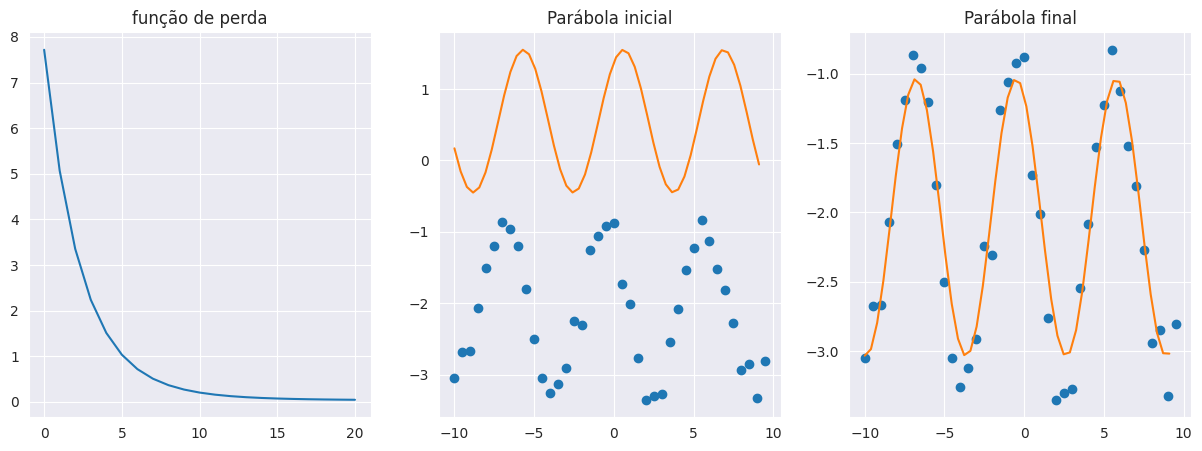

In [21]:
def plota_parabola(x, y, a, b):
    step = (x.max() - x.min()) / 50
    view_x = np.arange(x.min(), x.max(), step)
    view_y = [calcula_funcao(a, b, xi) for xi in view_x]
    plt.plot(x, y, 'o')
    plt.plot(view_x, view_y, '-')

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("função de perda")
plt.plot([epoch['loss'] for epoch in history], '-')

plt.subplot(1, 3, 2)
plt.title("Parábola inicial")
a, b =  history[0]["params"]
plota_parabola(x, y, a, b)

plt.subplot(1, 3, 3)
plt.title("Parábola final")
a, b =  history[-1]["params"]
plota_parabola(x, y, a, b)
